In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Mounted at /content/drive
Device: cuda


In [3]:
MODEL_READY_DIR = Path('/content/drive/MyDrive/model_ready')
MODELS_DIR      = Path('/content/drive/MyDrive/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train    = np.load(MODEL_READY_DIR / "X_train.npy").astype(np.float32)
y_train    = np.load(MODEL_READY_DIR / "y_train.npy").astype(np.float32)
cond_train = np.load(MODEL_READY_DIR / "cond_train.npy")
X_test     = np.load(MODEL_READY_DIR / "X_test.npy").astype(np.float32)
y_test     = np.load(MODEL_READY_DIR / "y_test.npy").astype(np.float32)
cond_test  = np.load(MODEL_READY_DIR / "cond_test.npy")

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")


X_train: (125618, 50, 16)
y_train: (125618,)
X_test:  (707, 50, 16)
y_test:  (707,)


In [4]:
class CNNBiLSTM(nn.Module):
    def __init__(self, input_size, num_filters, kernel_size, hidden_size, num_layers, dropout):
        super(CNNBiLSTM, self).__init__()

        # CNN layers
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, num_filters, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.BatchNorm1d(num_filters),
            nn.Conv1d(num_filters, num_filters, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(),
            nn.BatchNorm1d(num_filters)
        )

        # BiLSTM layer
        self.bilstm = nn.LSTM(
            input_size=num_filters,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
            bidirectional=True
        )

        # output layer
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1)          # → (batch, features, seq_len) for CNN
        x = self.cnn(x)                  # → (batch, num_filters, seq_len)
        x = x.permute(0, 2, 1)          # → (batch, seq_len, num_filters) for LSTM
        x, _ = self.bilstm(x)           # → (batch, seq_len, hidden*2)
        x = x[:, -1, :]                 # take last timestep
        x = self.fc(x)                  # → (batch, 1)
        return x.squeeze(1)             # → (batch,)


In [5]:
def train_model(model, train_loader, epochs, lr, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        scheduler.step(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

    return losses


In [6]:
# 10% data for search
search_size = int(len(X_train) * 0.10)
idx         = np.random.choice(len(X_train), size=search_size, replace=False)
X_search    = X_train[idx]
y_search    = y_train[idx]

print(f"Search size: {len(X_search)}")

X_search_tensor = torch.tensor(X_search)
y_search_tensor = torch.tensor(y_search)
search_dataset  = TensorDataset(X_search_tensor, y_search_tensor)
search_loader   = DataLoader(search_dataset, batch_size=256, shuffle=True)

input_size = X_train.shape[2]

def objective(trial):
    num_filters  = trial.suggest_categorical("num_filters",  [32, 64, 128])
    kernel_size  = trial.suggest_categorical("kernel_size",  [3, 5, 7])
    hidden_size  = trial.suggest_categorical("hidden_size",  [32, 64, 128])
    num_layers   = trial.suggest_categorical("num_layers",   [1, 2])
    lr           = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout      = trial.suggest_float("dropout", 0.1, 0.4)

    model = CNNBiLSTM(
        input_size=input_size,
        num_filters=num_filters,
        kernel_size=kernel_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    losses = train_model(model, search_loader, epochs=10, lr=lr, device=device)
    return losses[-1]

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15, show_progress_bar=True)

best_params = study.best_params
best_loss   = study.best_value
print(f"\nBest params: {best_params}")
print(f"Best loss:   {best_loss:.4f}")


Search size: 12561


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 10/10 — Loss: 379.5386
Epoch 10/10 — Loss: 256.4434
Epoch 10/10 — Loss: 340.7582
Epoch 10/10 — Loss: 300.2133
Epoch 10/10 — Loss: 397.2698
Epoch 10/10 — Loss: 368.7181
Epoch 10/10 — Loss: 350.0571
Epoch 10/10 — Loss: 514.4194
Epoch 10/10 — Loss: 526.4938
Epoch 10/10 — Loss: 3350.4632
Epoch 10/10 — Loss: 325.7198
Epoch 10/10 — Loss: 253.1536
Epoch 10/10 — Loss: 265.7400
Epoch 10/10 — Loss: 286.9230
Epoch 10/10 — Loss: 249.5857

Best params: {'num_filters': 64, 'kernel_size': 3, 'hidden_size': 128, 'num_layers': 2, 'lr': 0.000830315325478894, 'dropout': 0.15199452886924075}
Best loss:   249.5857


Retraining best model on full data for 100 epochs...
Epoch 10/100 — Loss: 128.5269
Epoch 20/100 — Loss: 73.3567
Epoch 30/100 — Loss: 60.9075
Epoch 40/100 — Loss: 54.1709
Epoch 50/100 — Loss: 52.9399
Epoch 60/100 — Loss: 47.2890
Epoch 70/100 — Loss: 47.1002
Epoch 80/100 — Loss: 42.7383
Epoch 90/100 — Loss: 42.7974
Epoch 100/100 — Loss: 39.8760


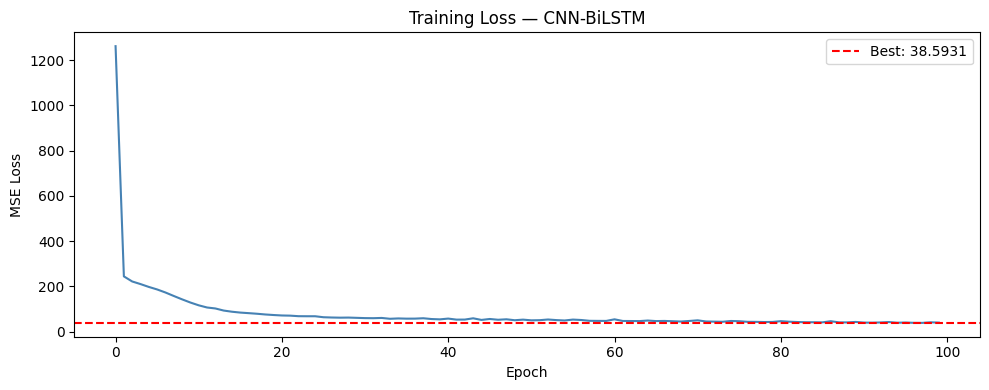

In [7]:
print("Retraining best model on full data for 100 epochs...")

X_full_tensor = torch.tensor(X_train)
y_full_tensor = torch.tensor(y_train)
full_dataset  = TensorDataset(X_full_tensor, y_full_tensor)
full_loader   = DataLoader(full_dataset, batch_size=256, shuffle=True)

final_model = CNNBiLSTM(
    input_size=input_size,
    num_filters=best_params["num_filters"],
    kernel_size=best_params["kernel_size"],
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout=best_params["dropout"]
).to(device)

losses = train_model(final_model, full_loader, epochs=100, lr=best_params["lr"], device=device)

plt.figure(figsize=(10, 4))
plt.plot(losses, color="steelblue")
plt.axhline(min(losses), color="red", linestyle="--", label=f"Best: {min(losses):.4f}")
plt.title("Training Loss — CNN-BiLSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


MAE:  12.20 cycles
RMSE: 17.58 cycles


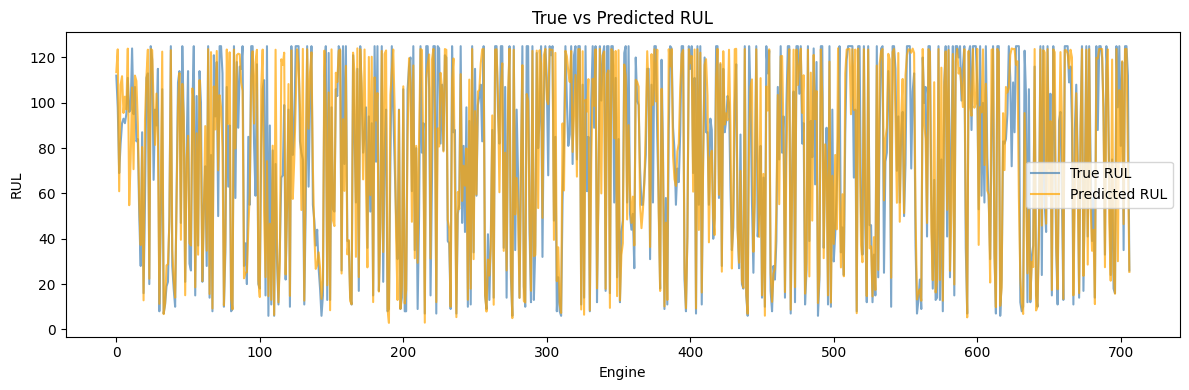

In [8]:
final_model.eval()

def predict(model, X, batch_size=256):
    preds = []
    dataset = TensorDataset(torch.tensor(X))
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            out = model(x)
            preds.extend(out.cpu().numpy())

    return np.array(preds)

y_pred = predict(final_model, X_test)

# metrics
mae  = np.mean(np.abs(y_pred - y_test))
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")

# plot
plt.figure(figsize=(12, 4))
plt.plot(y_test,  label="True RUL",      color="steelblue", alpha=0.7)
plt.plot(y_pred,  label="Predicted RUL", color="orange",    alpha=0.7)
plt.title("True vs Predicted RUL")
plt.xlabel("Engine")
plt.ylabel("RUL")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
torch.save({
    "model_state_dict" : final_model.state_dict(),
    "best_params"      : best_params,
    "input_size"       : input_size,
    "mae"              : mae,
    "rmse"             : rmse
}, MODELS_DIR / "agent2_rul_predictor.pt")

print(f"Agent 2 saved!")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


Agent 2 saved!
MAE:  12.20
RMSE: 17.58
